# Import Libraries

In [1]:
# Import required libraries
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.cluster import DBSCAN, KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor


# Function 1: K-Means Based Anomaly Detection

In [2]:
def detect_anomalies_kmeans(data):

    # Copy dataset to avoid modifying original data
    df = data.copy()

    # Standardize features so clustering works correctly
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(df)

    # Create K-Means model with 2 clusters
    # One cluster typically contains normal data
    # The other may contain anomalies
    kmeans = KMeans(n_clusters=2, random_state=42)

    # Train model
    kmeans.fit(scaled_data)

    # Predict cluster labels
    labels = kmeans.predict(scaled_data)

    # Add cluster labels to dataframe
    df['Cluster'] = labels

    # Assume cluster 1 contains anomalies
    anomalies_kmeans = df[df['Cluster'] == 1]

    return anomalies_kmeans


# Function 2: Isolation Forest

In [3]:
def detect_anomalies_if(data):

    df = data.copy()

    # Isolation Forest isolates anomalies by random partitioning
    model_if = IsolationForest(
        contamination=0.05,   # Assume 5% anomalies
        random_state=42
    )

    # Train model
    model_if.fit(df)

    # Predict anomalies
    # -1 = anomaly
    #  1 = normal
    df['Anomaly_IF'] = model_if.predict(df)

    # Filter anomalies
    anomalies_if = df[df['Anomaly_IF'] == -1]

    return anomalies_if

# Function 3: One-Class SVM

In [13]:
def detect_anomalies_svm(data):

    df = data.copy()

    # One-Class SVM learns the boundary of normal data
    model_svm = OneClassSVM(
        nu=0.05,        # Approximate percentage of anomalies
        kernel="rbf"
    )

    # Train model
    model_svm.fit(df)

    # Predict anomalies
    df['Anomaly_SVM'] = model_svm.predict(df)

    # Extract anomalies
    anomalies_svm = df[df['Anomaly_SVM'] == -1]

    # Note: To visualize anomalies related to a specific feature like 'login_attempts',
    # ensure 'login_attempts' is part of the 'data' DataFrame
    # and then create a separate plot using 'anomalies_svm' dataframe.

    return anomalies_svm

# Function 4: DBSCAN Density-Based Detection

In [5]:
def detect_anomalies_dbscan(data):

    df = data.copy()

    # Standardize features
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(df)

    # DBSCAN identifies points in low density regions
    model_dbscan = DBSCAN(
        eps=0.5,
        min_samples=5
    )

    # Train model
    model_dbscan.fit(scaled_data)

    # DBSCAN labels
    # -1 = anomaly / noise
    df['Anomaly_DBSCAN'] = model_dbscan.labels_

    anomalies_dbscan = df[df['Anomaly_DBSCAN'] == -1]

    return anomalies_dbscan

# Function 5: Local Outlier Factor (LOF)

In [6]:
def detect_anomalies_lof(data):

    df = data.copy()

    # LOF compares local density of points
    model_lof = LocalOutlierFactor(
        contamination=0.05
    )

    # Fit and predict
    df['Anomaly_LOF'] = model_lof.fit_predict(df)

    # Extract anomalies
    anomalies_lof = df[df['Anomaly_LOF'] == -1]

    return anomalies_lof

# Code to Run the Project

In [8]:
import pandas as pd
import numpy as np

# from anomaly_models import * # Removed this line as functions are defined in the notebook

# Load dataset
df = pd.read_csv("logging_monitoring_anomalies.csv")

# Remove non-numeric columns
df_numeric = df.select_dtypes(include=[np.number])

# Run algorithms
kmeans_anomalies = detect_anomalies_kmeans(df_numeric)
if_anomalies = detect_anomalies_if(df_numeric)
svm_anomalies = detect_anomalies_svm(df_numeric)
dbscan_anomalies = detect_anomalies_dbscan(df_numeric)
lof_anomalies = detect_anomalies_lof(df_numeric)

# Print results
print("KMeans anomalies:", len(kmeans_anomalies))
print("Isolation Forest anomalies:", len(if_anomalies))
print("SVM anomalies:", len(svm_anomalies))
print("DBSCAN anomalies:", len(dbscan_anomalies))
print("LOF anomalies:", len(lof_anomalies))

KMeans anomalies: 49841
Isolation Forest anomalies: 5000
SVM anomalies: 5000
DBSCAN anomalies: 100000
LOF anomalies: 5000


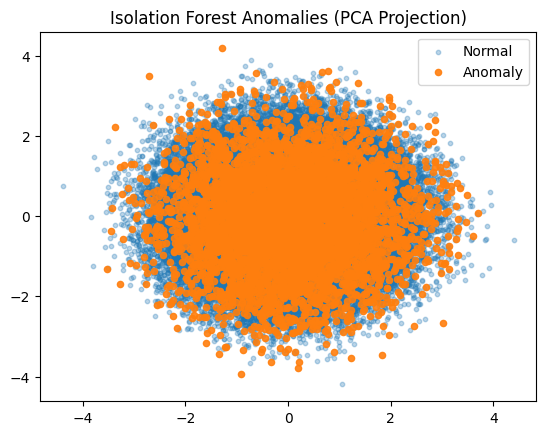

In [19]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Scale data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_numeric)

# PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(pca_result, columns=['PC1','PC2'])

# Add anomaly labels
# Create a boolean mask for the entire df_numeric indicating which rows are anomalies
# This ensures the mask has the same length as pca_df
anomaly_mask = df_numeric.index.isin(if_anomalies.index)
pca_df['Anomaly'] = anomaly_mask

plt.figure()

normal = df_numeric.index.difference(if_anomalies.index)

plt.scatter(pca_df.loc[normal,'PC1'],pca_df.loc[normal,'PC2'],s=10,alpha=0.3,label="Normal")

plt.scatter(pca_df.loc[if_anomalies.index,'PC1'],pca_df.loc[if_anomalies.index,'PC2'],s=20,alpha=0.9,label="Anomaly")

plt.legend()
plt.title("Isolation Forest Anomalies (PCA Projection)")
plt.show()


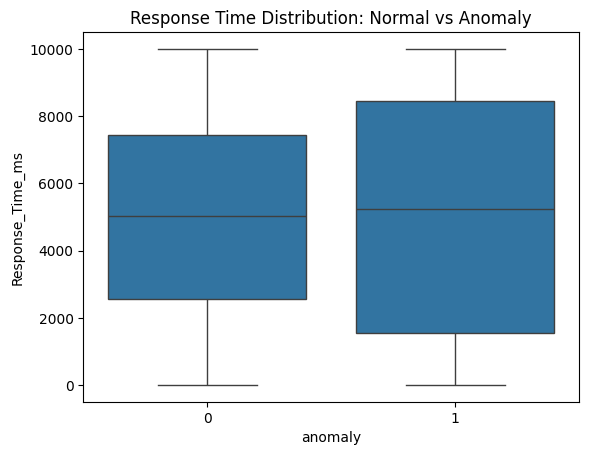

In [20]:
import seaborn as sns

df_plot = df_numeric.copy()
df_plot['anomaly'] = 0
df_plot.loc[if_anomalies.index,'anomaly'] = 1

plt.figure()

sns.boxplot(
    x='anomaly',
    y='Response_Time_ms',
    data=df_plot
)

plt.title("Response Time Distribution: Normal vs Anomaly")

plt.show()

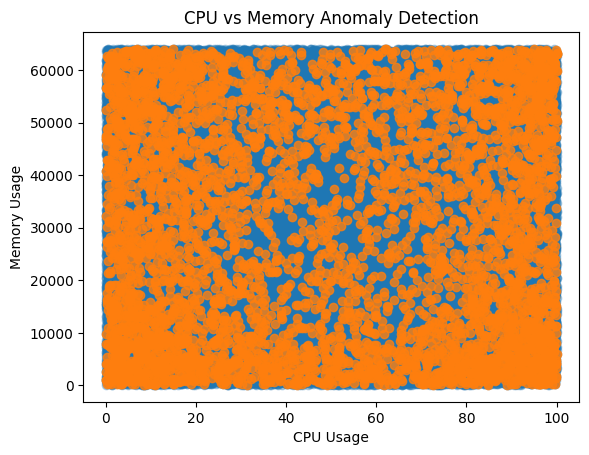

In [21]:
plt.figure()

plt.scatter(
    df_numeric['CPU_Usage_Percent'],
    df_numeric['Memory_Usage_MB'],
    alpha=0.3
)

plt.scatter(
    if_anomalies['CPU_Usage_Percent'],
    if_anomalies['Memory_Usage_MB'],
    alpha=0.8
)

plt.xlabel("CPU Usage")
plt.ylabel("Memory Usage")
plt.title("CPU vs Memory Anomaly Detection")

plt.show()

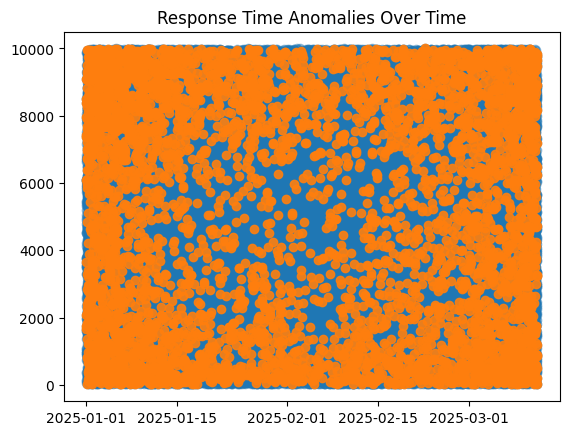

In [22]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

plt.figure()

plt.scatter(
    df['Timestamp'],
    df['Response_Time_ms'],
    alpha=0.4
)

plt.scatter(
    df.loc[if_anomalies.index,'Timestamp'],
    df.loc[if_anomalies.index,'Response_Time_ms'],
    alpha=0.9
)

plt.title("Response Time Anomalies Over Time")

plt.show()

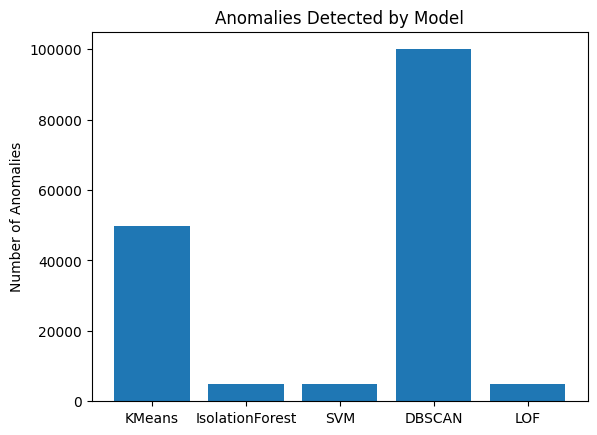

In [23]:
models = ['KMeans','IsolationForest','SVM','DBSCAN','LOF']

counts = [
len(kmeans_anomalies),
len(if_anomalies),
len(svm_anomalies),
len(dbscan_anomalies),
len(lof_anomalies)
]

plt.figure()

plt.bar(models,counts)

plt.title("Anomalies Detected by Model")

plt.ylabel("Number of Anomalies")

plt.show()

# Anomaly by variable investigation

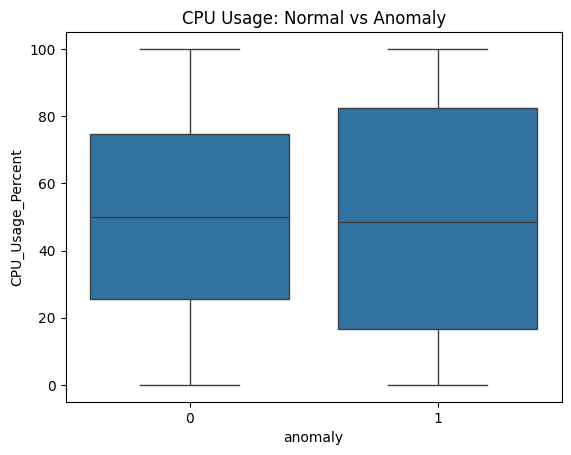

In [24]:
#Anomalies by Variables CPU USAGE
import seaborn as sns
import matplotlib.pyplot as plt

df_plot = df_numeric.copy()
df_plot['anomaly'] = 0
df_plot.loc[if_anomalies.index,'anomaly'] = 1

plt.figure()

sns.boxplot(
    x='anomaly',
    y='CPU_Usage_Percent',
    data=df_plot
)

plt.title("CPU Usage: Normal vs Anomaly")

plt.show()

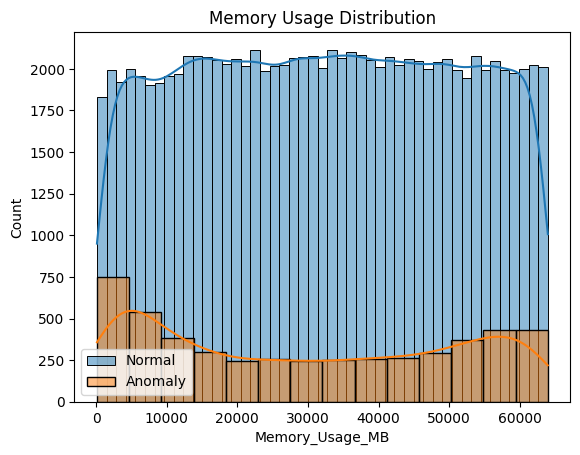

In [25]:
plt.figure()

sns.histplot(
    df_plot[df_plot['anomaly']==0]['Memory_Usage_MB'],
    kde=True,
    label="Normal"
)

sns.histplot(
    df_plot[df_plot['anomaly']==1]['Memory_Usage_MB'],
    kde=True,
    label="Anomaly"
)

plt.legend()
plt.title("Memory Usage Distribution")

plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


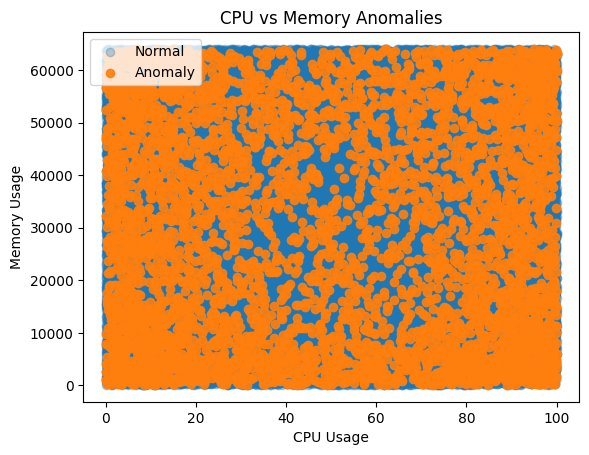

In [26]:
plt.figure()

plt.scatter(
    df_numeric['CPU_Usage_Percent'],
    df_numeric['Memory_Usage_MB'],
    alpha=0.3,
    label="Normal"
)

plt.scatter(
    if_anomalies['CPU_Usage_Percent'],
    if_anomalies['Memory_Usage_MB'],
    alpha=0.9,
    label="Anomaly"
)

plt.legend()

plt.xlabel("CPU Usage")
plt.ylabel("Memory Usage")

plt.title("CPU vs Memory Anomalies")

plt.show()

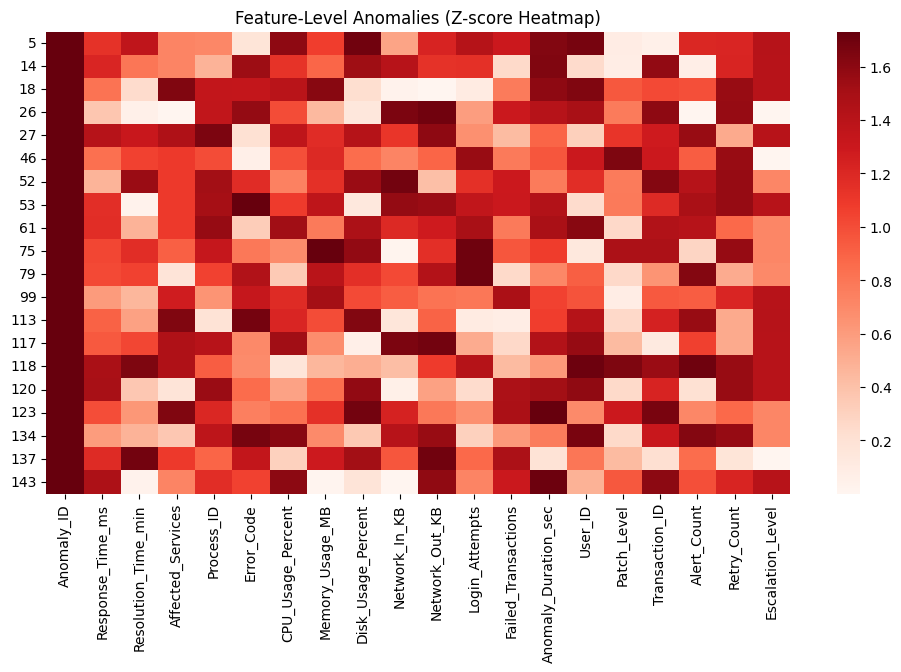

In [27]:
from scipy.stats import zscore

z_scores = np.abs(zscore(df_numeric))

z_df = pd.DataFrame(z_scores, columns=df_numeric.columns)

anomaly_rows = z_df.loc[if_anomalies.index]

plt.figure(figsize=(12,6))

sns.heatmap(
    anomaly_rows.head(20),
    cmap="Reds"
)

plt.title("Feature-Level Anomalies (Z-score Heatmap)")

plt.show()